# ARTI 404 – Image Processing
## Lab 5: Spatial Filtering – Smoothing and Sharpening

**College of Computer Science and Information Technology – Department of Computer Engineering**
**Imam Abdulrahman Bin Faisal University – 2025/2026**

| | |
|---|---|
| **Student Name** | Nawaf Mohammed Alghamdi |
| **Student ID** | 2240007352 |


**Session outcome (Outcome #2):** Write a program that implements fundamental image processing algorithms.

**Contents**
1. **Procedural task**
   - Task 1 – Unsharp masking (Parrot image)
2. **Assessment tasks**
   - Task 1 – Convolution with a 7×7 box filter (Parrot image)
   - Task 2 – 5×5 and 21×21 Gaussian filters (astronaut image)
   - Task 3 – Sharpening with a 3×3 Laplacian filter (cameraman image)

## 0. Setup
Libraries used: OpenCV, NumPy, Pillow, scikit-image and Matplotlib.
Input images are kept in the `images/` folder and every figure produced by this notebook is saved in the `outputs/` folder.

In [1]:
import os
import cv2
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import skimage
from PIL import Image
from skimage import data

IMG_DIR = 'images'    # input images used in this lab
OUT_DIR = 'outputs'   # figures produced by this notebook
os.makedirs(IMG_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)
plt.rcParams['figure.dpi'] = 80   # keeps the notebook file small enough for GitHub to display

print('OpenCV      :', cv2.__version__)
print('NumPy       :', np.__version__)
print('scikit-image:', skimage.__version__)
print('Matplotlib  :', matplotlib.__version__)

OpenCV      : 5.0.0
NumPy       : 2.5.3
scikit-image: 0.26.0
Matplotlib  : 3.11.2


The images *of my choice* for Assessment Tasks 2 and 3 come from `skimage.data` (astronaut and cameraman). A copy of
each is saved to `images/` so the submission folder contains every image used (the Parrot image is already in
`images/Parrot.png`).

A helper function measures **sharpness** as the variance of the Laplacian of the grayscale image (a common focus
measure): smoothing lowers it, sharpening raises it. It is used to check every result numerically.

In [2]:
samples = {'astronaut.png': data.astronaut(), 'camera.png': data.camera()}
for name, im in samples.items():
    Image.fromarray(im).save(os.path.join(IMG_DIR, name))
    print(f'saved images/{name:14s} shape={im.shape}, dtype={im.dtype}')
print('images folder:', sorted(os.listdir(IMG_DIR)))


def sharpness(img):
    # Variance of the Laplacian of the grayscale image (images scaled to [0, 1])
    f = img.astype(np.float32)
    if f.max() > 1.0:
        f = f / 255.0
    if f.ndim == 3:
        f = cv2.cvtColor(f, cv2.COLOR_RGB2GRAY)
    return cv2.Laplacian(f, cv2.CV_32F, ksize=1).var()

saved images/astronaut.png  shape=(512, 512, 3), dtype=uint8
saved images/camera.png     shape=(512, 512), dtype=uint8
images folder: ['Parrot.png', 'astronaut.png', 'camera.png']


---
# Part A – Procedural Task
## Task 1: Unsharp Masking

Unsharp masking sharpens an image by **adding back the detail that a blur removes**:

1. Blur the image with a Gaussian filter: $\bar f(x,y) = G_\sigma * f(x,y)$
2. Build the mask (the high-frequency detail): $g_{mask}(x,y) = f(x,y) - \bar f(x,y)$
3. Add a weighted mask to the original: $g(x,y) = f(x,y) + k \cdot g_{mask}(x,y)$

Here $\sigma = 2$ and $k$ = `amount` = 1.5 (with $k > 1$ this is also called *highboost filtering*).

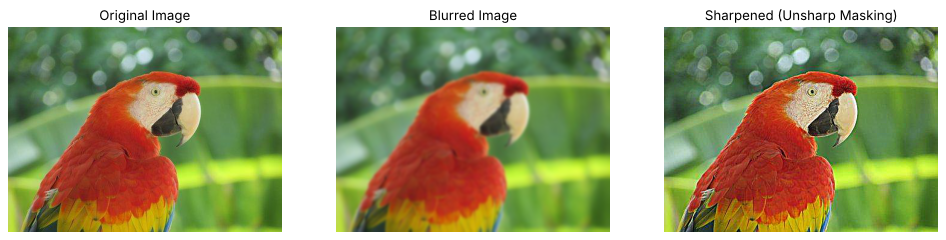

Sharpness (variance of Laplacian): original = 0.00681, blurred = 0.00002, sharpened = 0.03500


In [3]:
# Read the image
image = cv2.imread(os.path.join(IMG_DIR, 'Parrot.png'))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert from BGR to RGB

# Gaussian sigma
sigma = 2
# parameter
amount = 1.5

# Convert image to float32 for processing
image_float = image.astype(np.float32) / 255.0

# Apply Gaussian blur
blurred = cv2.GaussianBlur(image_float, (0, 0), sigmaX=sigma, sigmaY=sigma)

# Perform Unsharp Masking
sharpened = np.clip(image_float + amount * (image_float - blurred), 0, 1)

# Plot original, blurred, and sharpened images
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(image)
ax[0].set_title("Original Image")
ax[0].axis("off")
ax[1].imshow(blurred)
ax[1].set_title("Blurred Image")
ax[1].axis("off")
ax[2].imshow(sharpened)
ax[2].set_title("Sharpened (Unsharp Masking)")
ax[2].axis("off")
plt.savefig(os.path.join(OUT_DIR, 'A1_unsharp_masking.png'), dpi=110, bbox_inches='tight')
plt.show()

print(f'Sharpness (variance of Laplacian): original = {sharpness(image_float):.5f}, '
      f'blurred = {sharpness(blurred):.5f}, sharpened = {sharpness(sharpened):.5f}')

**The mask and a close-up.** The mask $f - \bar f$ contains only edges and fine texture (shown here scaled so that 0 is
mid-gray). The close-up of the eye and beak compares the effect of different `amount` values.

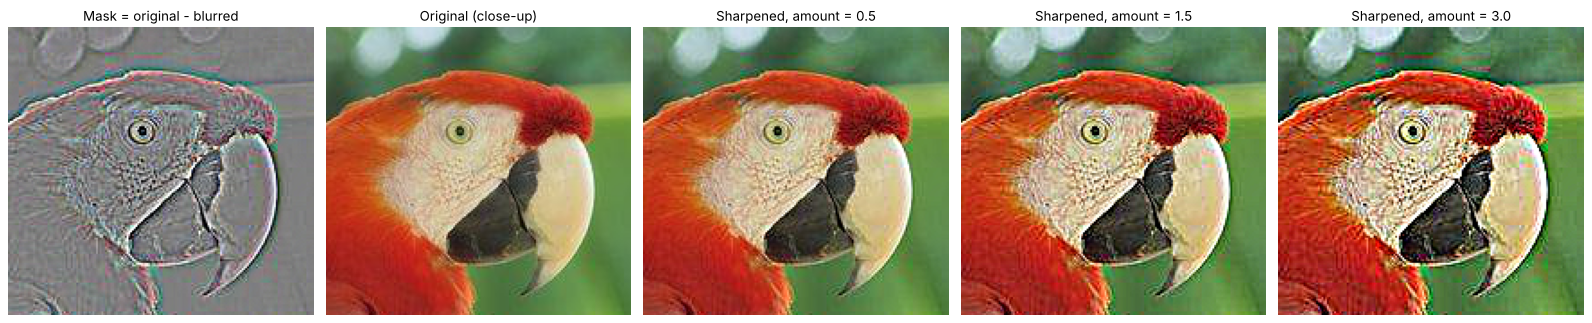

amount = 0.5: sharpness = 0.01460, values clipped to 0 or 1 = 0.8%
amount = 1.5: sharpness = 0.03500, values clipped to 0 or 1 = 1.9%
amount = 3.0: sharpness = 0.06960, values clipped to 0 or 1 = 3.8%


In [4]:
mask = image_float - blurred                    # high-frequency detail
mask_vis = np.clip(0.5 + 2.5 * mask, 0, 1)      # 0 -> mid-gray, amplified for visibility

y0, y1, x0, x1 = 50, 210, 170, 340              # close-up: eye and beak
amounts = [0.5, 1.5, 3.0]

fig, ax = plt.subplots(1, 5, figsize=(20, 4.4))
ax[0].imshow(mask_vis[y0:y1, x0:x1])
ax[0].set_title('Mask = original - blurred')
ax[1].imshow(image[y0:y1, x0:x1])
ax[1].set_title('Original (close-up)')
for a, k in zip(ax[2:], amounts):
    s = np.clip(image_float + k * mask, 0, 1)
    a.imshow(s[y0:y1, x0:x1])
    a.set_title(f'Sharpened, amount = {k}')
for a in ax:
    a.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'A1_unsharp_mask_closeup.png'), dpi=110, bbox_inches='tight')
plt.show()

for k in amounts:
    s = np.clip(image_float + k * mask, 0, 1)
    clipped = 100 * np.mean((s == 0) | (s == 1))
    print(f'amount = {k}: sharpness = {sharpness(s):.5f}, values clipped to 0 or 1 = {clipped:.1f}%')

### Observations – Task 1 (Unsharp masking)
- The **blurred** image (Gaussian, σ = 2) loses its fine detail: the feathers, the ring around the eye and the edges of the beak become soft. The sharpness measure drops from 0.00681 to 0.00002.
- The **mask** (original − blurred) is close to zero (mid-gray) in flat areas such as the smooth green background and is non-zero only along edges and texture: it holds exactly the high-frequency detail that the blur removed.
- Adding 1.5 × the mask back to the original makes the beak outline, the eye and the feather texture clearly crisper. The sharpness rises from 0.00681 to 0.03500 (about 5 times higher), while the flat regions, the overall brightness and the colours stay the same.
- **Effect of `amount`:** 0.5 gives a subtle improvement, 1.5 gives clear sharpening, and 3.0 over-sharpens the image: bright and dark **halos** appear along the beak and head outline, background noise and compression artefacts are amplified, and more pixels are clipped (0.8 % → 1.9 % → 3.8 %).
- Thin coloured fringes appear at strong edges because each RGB channel is sharpened separately.

---
# Part B – Assessment Tasks

## Assessment Task 1: Convolution with a 7×7 box filter
A box (mean) filter replaces every pixel by the **average of its 7×7 neighbourhood**. Its kernel has 49 equal
coefficients:

$$ w = \frac{1}{49}\begin{bmatrix} 1 & \cdots & 1 \\ \vdots & \ddots & \vdots \\ 1 & \cdots & 1 \end{bmatrix}_{7\times 7},
\qquad g(x,y) = \sum_{s=-3}^{3}\sum_{t=-3}^{3} w(s,t)\, f(x+s, y+t) $$

The convolution is done with `cv2.filter2D` and the explicit kernel (the box kernel is symmetric, so correlation and
convolution give the same result). The result is checked against OpenCV's built-in `cv2.blur`.

7x7 box kernel (each coefficient = 1/49 = 0.0204), sum = 1.0
Identical to cv2.blur(img, (7, 7)): True
Sharpness: original = 0.00681, smoothed = 0.00005


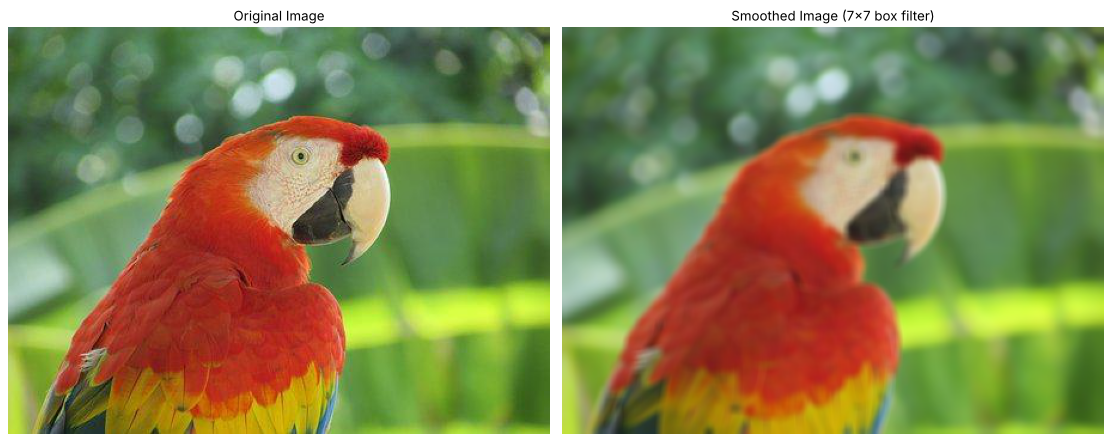

In [5]:
# Read the image
img = cv2.cvtColor(cv2.imread(os.path.join(IMG_DIR, 'Parrot.png')), cv2.COLOR_BGR2RGB)

# 7x7 box filter kernel
kernel_box = np.ones((7, 7), np.float32) / 49
print('7x7 box kernel (each coefficient = 1/49 = %.4f), sum = %.1f' % (kernel_box[0, 0], kernel_box.sum()))

# Convolve the image with the kernel
smoothed_box = cv2.filter2D(img, -1, kernel_box)

# Check: same result as OpenCV's box filter
print('Identical to cv2.blur(img, (7, 7)):', np.array_equal(smoothed_box, cv2.blur(img, (7, 7))))
print(f'Sharpness: original = {sharpness(img):.5f}, smoothed = {sharpness(smoothed_box):.5f}')

# Output the original and smoothed image side by side
fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))
ax[0].imshow(img)
ax[0].set_title('Original Image')
ax[1].imshow(smoothed_box)
ax[1].set_title('Smoothed Image (7x7 box filter)')
for a in ax:
    a.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'B1_box_filter_7x7.png'), dpi=110, bbox_inches='tight')
plt.show()

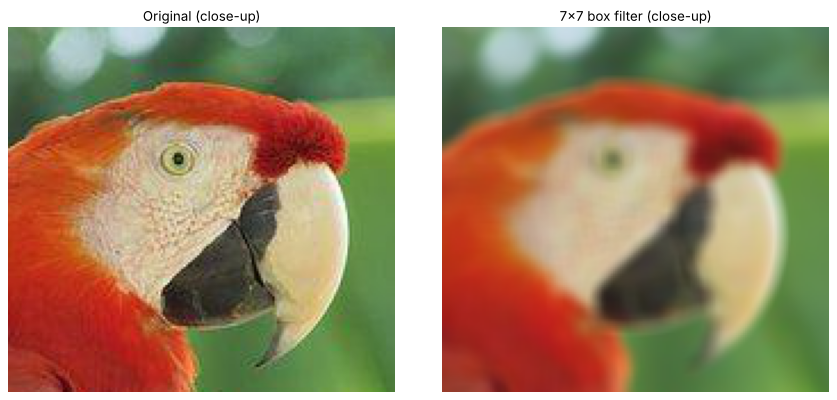

In [6]:
# Close-up of the eye and beak
y0, y1, x0, x1 = 50, 210, 170, 340
fig, ax = plt.subplots(1, 2, figsize=(11, 5))
ax[0].imshow(img[y0:y1, x0:x1])
ax[0].set_title('Original (close-up)')
ax[1].imshow(smoothed_box[y0:y1, x0:x1])
ax[1].set_title('7x7 box filter (close-up)')
for a in ax:
    a.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'B1_box_filter_closeup.png'), dpi=110, bbox_inches='tight')
plt.show()

### Observations – Assessment Task 1 (7×7 box filter)
- Every kernel coefficient is 1/49 ≈ 0.0204 and the coefficients sum to 1, so the filter only averages: the overall brightness of the image is preserved.
- The result of `cv2.filter2D` with the explicit kernel is **identical** to `cv2.blur(img, (7, 7))`, which confirms the convolution is implemented correctly.
- The smoothed image is clearly blurred: the feather texture, the details of the eye and the crack in the beak disappear, and sharp edges become soft ramps about 7 pixels wide. The sharpness measure drops from 0.00681 to 0.00005 (more than 99 % lower).
- All 49 neighbours get the **same weight**, no matter how far they are from the centre, so the blur is strong for the kernel size and small bright details are spread into square-shaped blobs. A Gaussian filter (Task 2), whose weights fall off with distance, gives a more natural blur.
- OpenCV handles the image borders by reflection, so the output has the same size as the input.

## Assessment Task 2: 5×5 and 21×21 Gaussian filters
Image of my choice: **astronaut** (`skimage.data.astronaut`).

A Gaussian filter weights the neighbours by a 2-D Gaussian, $G(s,t) = \frac{1}{2\pi\sigma^2} e^{-(s^2+t^2)/2\sigma^2}$,
so pixels close to the centre count more than distant ones. With `sigmaX = 0`, OpenCV computes $\sigma$ from the
kernel size: $\sigma = 0.3\,((k_{size}-1)\cdot 0.5 - 1) + 0.8$, which gives $\sigma = 1.1$ for 5×5 and $\sigma = 3.5$ for 21×21.

5x5 Gaussian: sigma = 1.10, centre weight (1-D) = 0.3750, edge weight (1-D) = 0.0625
21x21 Gaussian: sigma = 3.50, centre weight (1-D) = 0.1143, edge weight (1-D) = 0.0019
5x5 1-D kernel: [0.0625 0.25   0.375  0.25   0.0625]
Sharpness: original = 0.01321, 5x5 = 0.00092, 21x21 = 0.00004


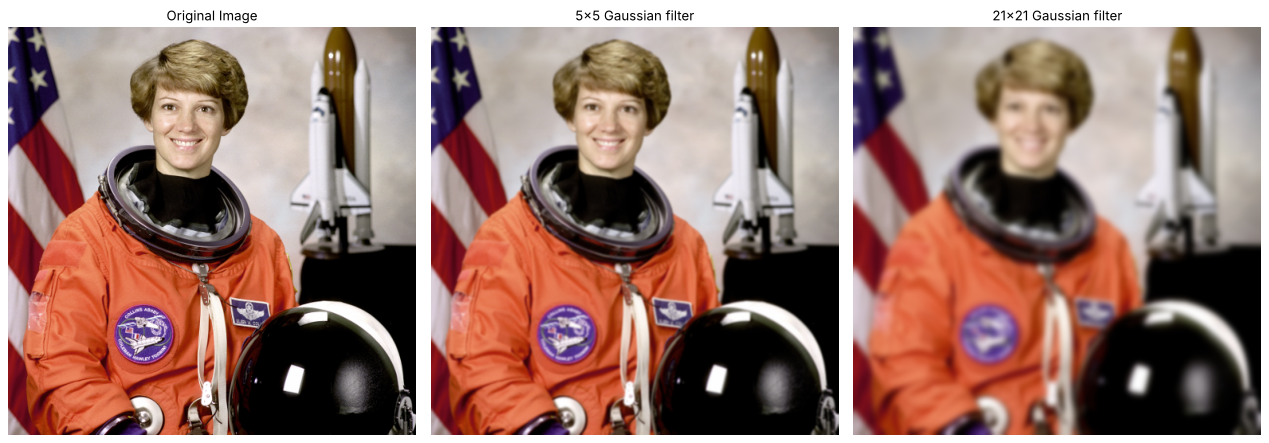

In [7]:
# Read the image of my choice
img2 = cv2.cvtColor(cv2.imread(os.path.join(IMG_DIR, 'astronaut.png')), cv2.COLOR_BGR2RGB)

# Apply a 5x5 Gaussian filter, then a 21x21 Gaussian filter (sigma computed from the kernel size)
gauss_5 = cv2.GaussianBlur(img2, (5, 5), 0)
gauss_21 = cv2.GaussianBlur(img2, (21, 21), 0)

for k in (5, 21):
    g = cv2.getGaussianKernel(k, 0).ravel()
    sigma_k = 0.3 * ((k - 1) * 0.5 - 1) + 0.8
    print(f'{k}x{k} Gaussian: sigma = {sigma_k:.2f}, centre weight (1-D) = {g[k // 2]:.4f}, '
          f'edge weight (1-D) = {g[0]:.4f}')
print(f'5x5 1-D kernel: {np.round(cv2.getGaussianKernel(5, 0).ravel(), 4)}')
print(f'Sharpness: original = {sharpness(img2):.5f}, 5x5 = {sharpness(gauss_5):.5f}, '
      f'21x21 = {sharpness(gauss_21):.5f}')

# Show the three images side by side
fig, ax = plt.subplots(1, 3, figsize=(16, 5.4))
for a, im, title in zip(ax, (img2, gauss_5, gauss_21),
                        ('Original Image', '5x5 Gaussian filter', '21x21 Gaussian filter')):
    a.imshow(im)
    a.set_title(title)
    a.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'B2_gaussian_5_21.png'), dpi=110, bbox_inches='tight')
plt.show()

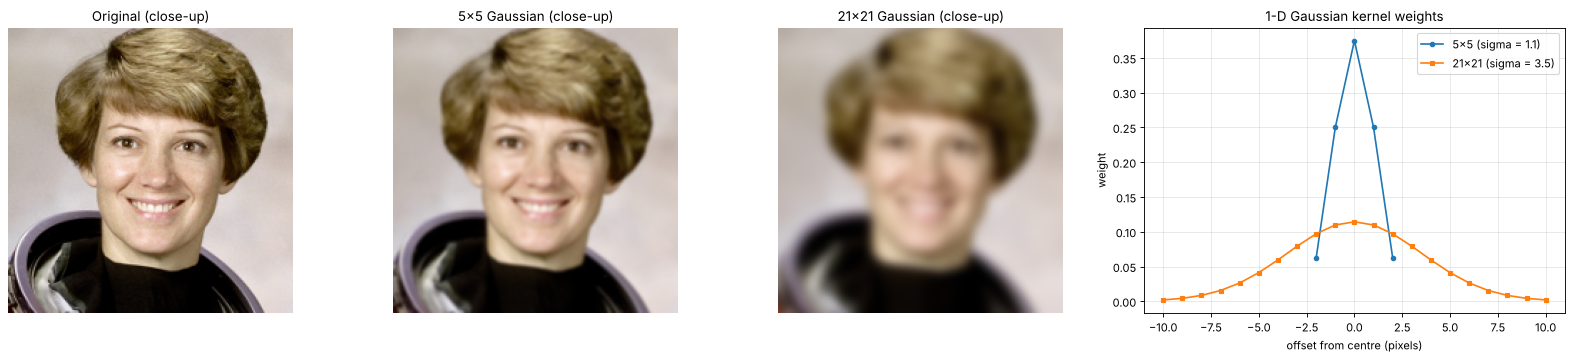

In [8]:
# Close-up of the face, and the shape of the two 1-D Gaussian kernels
y0, y1, x0, x1 = 20, 220, 120, 320
fig, ax = plt.subplots(1, 4, figsize=(20, 4.6), gridspec_kw={'width_ratios': [1, 1, 1, 1.3]})
for a, im, title in zip(ax[:3], (img2, gauss_5, gauss_21), ('Original', '5x5 Gaussian', '21x21 Gaussian')):
    a.imshow(im[y0:y1, x0:x1])
    a.set_title(title + ' (close-up)')
    a.axis('off')
for k, style in ((5, 'o-'), (21, 's-')):
    g = cv2.getGaussianKernel(k, 0).ravel()
    ax[3].plot(np.arange(k) - k // 2, g, style, ms=4, label=f'{k}x{k} (sigma = {0.3 * ((k - 1) * 0.5 - 1) + 0.8:.1f})')
ax[3].set_title('1-D Gaussian kernel weights')
ax[3].set_xlabel('offset from centre (pixels)')
ax[3].set_ylabel('weight')
ax[3].legend()
ax[3].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'B2_gaussian_closeup_kernels.png'), dpi=110, bbox_inches='tight')
plt.show()

### Observations – Assessment Task 2 (5×5 and 21×21 Gaussian filters)
- **5×5 (σ ≈ 1.1):** the weights are [1, 4, 6, 4, 1]/16 in each direction, so the centre pixel dominates (weight 0.375). The smoothing is mild: skin texture, hair strands and the small text on the badge soften, but the face, the flag and the shuttle are still sharp enough to recognise. Sharpness: 0.01321 → 0.00092.
- **21×21 (σ = 3.5):** the weights are spread over ±10 pixels (centre 0.114, outer edge 0.002). The blur is strong: the text on the badge becomes unreadable, the eyes and teeth disappear, and only the large shapes and colour regions remain. Sharpness: 0.00004.
- A larger kernel (and the larger σ that comes with it) averages more neighbours, so it removes more detail. The kernel plot shows the 21×21 Gaussian is much wider and flatter than the 5×5 one.
- Because the Gaussian weights decrease smoothly with distance, edges fade out softly and the result looks natural, without the square-shaped artefacts of the box filter.
- The 21×21 kernel is about 6σ wide, which is the size needed to contain almost the entire Gaussian; a larger kernel with the same σ would add only near-zero weights.

## Assessment Task 3: Sharpening with a 3×3 Laplacian filter
Image of my choice: **cameraman** (`skimage.data.camera`).

The Laplacian is a second-derivative operator, $\nabla^2 f = \frac{\partial^2 f}{\partial x^2} + \frac{\partial^2 f}{\partial y^2}$.
Its 3×3 discrete version is

$$ \nabla^2 f(x,y) = f(x+1,y) + f(x-1,y) + f(x,y+1) + f(x,y-1) - 4f(x,y)
\quad\Longleftrightarrow\quad
\begin{bmatrix} 0 & 1 & 0 \\ 1 & -4 & 1 \\ 0 & 1 & 0 \end{bmatrix} $$

It is zero in flat regions and strong at edges and fine details. Because the centre coefficient is **negative**, the
image is sharpened by **subtracting** the Laplacian: $g(x,y) = f(x,y) - \nabla^2 f(x,y)$.

In OpenCV, `cv2.Laplacian(..., ksize=1)` uses exactly this 3×3 kernel (it is also the default `ksize`).

cv2.Laplacian(ksize=1) == filter2D with 3x3 kernel: True
Laplacian range: [-1.663, 1.102], mean = 0.00001
Sharpness: original = 0.01743, sharpened = 0.42140
Pixels clipped to 0 or 1 after sharpening: 5.7%


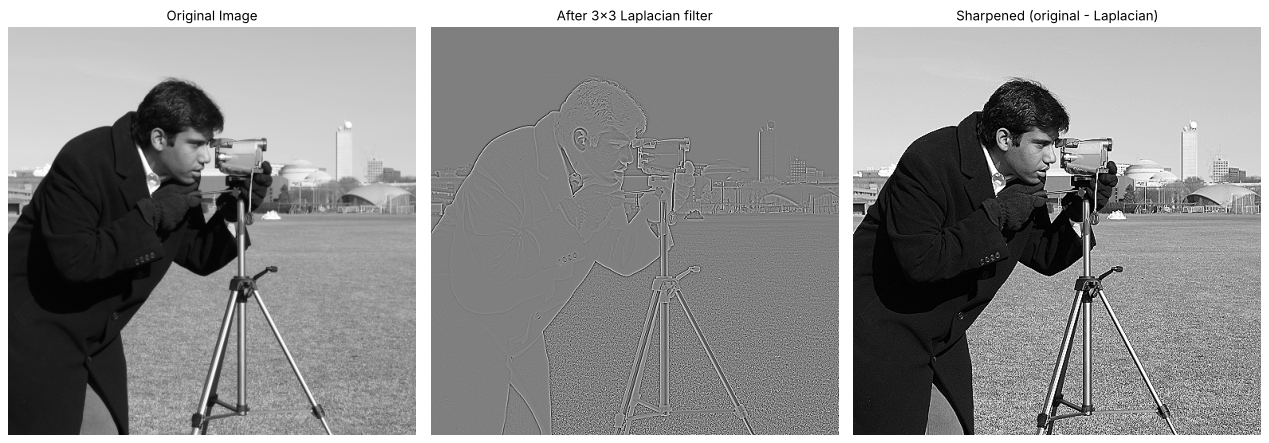

In [9]:
# 1. Read the image
img3 = cv2.imread(os.path.join(IMG_DIR, 'camera.png'), cv2.IMREAD_GRAYSCALE)

# 2. Convert image to float32
image_float = img3.astype(np.float32) / 255.0

# 3. Use the cv2.Laplacian() function (3x3 kernel [[0,1,0],[1,-4,1],[0,1,0]])
laplacian = cv2.Laplacian(image_float, cv2.CV_32F, ksize=1)

# 4. Sharpen the image
sharpened = np.clip(image_float - laplacian, 0, 1)

# check: cv2.Laplacian with ksize=1 is the same as convolving with the 3x3 kernel
kernel_lap = np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]], np.float32)
print('cv2.Laplacian(ksize=1) == filter2D with 3x3 kernel:',
      np.allclose(laplacian, cv2.filter2D(image_float, -1, kernel_lap)))
print(f'Laplacian range: [{laplacian.min():.3f}, {laplacian.max():.3f}], mean = {laplacian.mean():.5f}')
print(f'Sharpness: original = {sharpness(image_float):.5f}, sharpened = {sharpness(sharpened):.5f}')
print(f'Pixels clipped to 0 or 1 after sharpening: {100 * np.mean((sharpened == 0) | (sharpened == 1)):.1f}%')

# 5. Plot the original image, the Laplacian-filtered image and the sharpened image
lim = np.percentile(np.abs(laplacian), 99.5)       # symmetric display range, 0 -> mid-gray
fig, ax = plt.subplots(1, 3, figsize=(16, 5.4))
ax[0].imshow(image_float, cmap='gray', vmin=0, vmax=1)
ax[0].set_title('Original Image')
ax[1].imshow(laplacian, cmap='gray', vmin=-lim, vmax=lim)
ax[1].set_title('After 3x3 Laplacian filter')
ax[2].imshow(sharpened, cmap='gray', vmin=0, vmax=1)
ax[2].set_title('Sharpened (original - Laplacian)')
for a in ax:
    a.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'B3_laplacian_sharpening.png'), dpi=110, bbox_inches='tight')
plt.show()

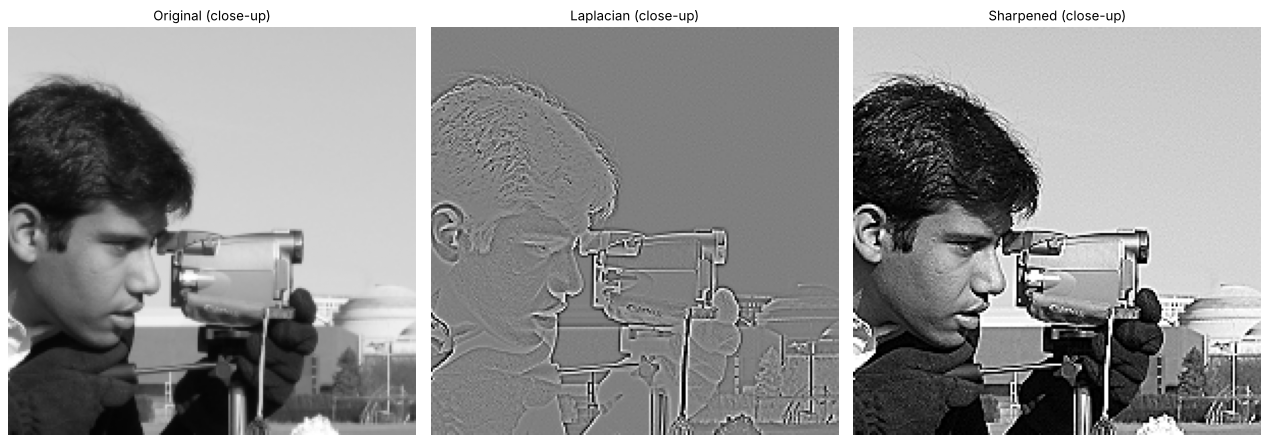

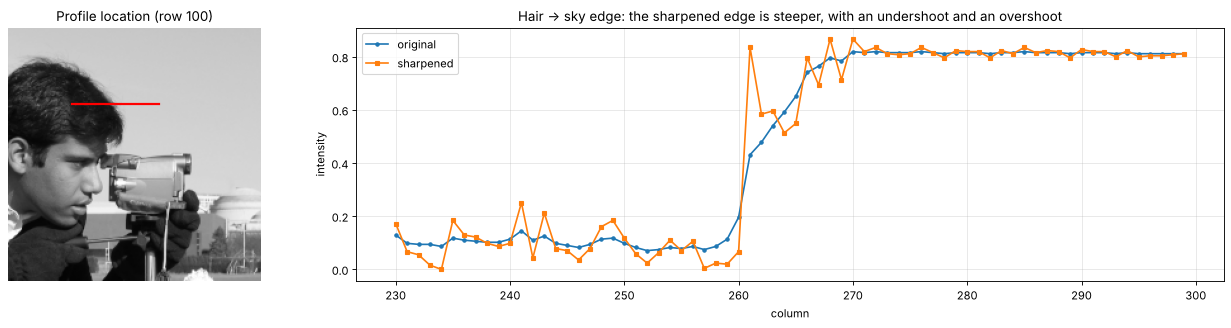

In [10]:
# Close-up of the head and the camera
y0, y1, x0, x1 = 40, 240, 180, 380
fig, ax = plt.subplots(1, 3, figsize=(16, 5.4))
ax[0].imshow(image_float[y0:y1, x0:x1], cmap='gray', vmin=0, vmax=1)
ax[0].set_title('Original (close-up)')
ax[1].imshow(laplacian[y0:y1, x0:x1], cmap='gray', vmin=-lim, vmax=lim)
ax[1].set_title('Laplacian (close-up)')
ax[2].imshow(sharpened[y0:y1, x0:x1], cmap='gray', vmin=0, vmax=1)
ax[2].set_title('Sharpened (close-up)')
for a in ax:
    a.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'B3_laplacian_closeup.png'), dpi=110, bbox_inches='tight')
plt.show()

# Intensity profile along one row crossing the edge between the hair and the sky
row, c0, c1 = 100, 230, 300
cols = np.arange(c0, c1)
fig, ax = plt.subplots(1, 2, figsize=(16, 4.2), gridspec_kw={'width_ratios': [1, 2.6]})
ax[0].imshow(image_float[y0:y1, x0:x1], cmap='gray', vmin=0, vmax=1)
ax[0].plot([c0 - x0, c1 - 1 - x0], [row - y0, row - y0], 'r-', linewidth=2)
ax[0].set_title(f'Profile location (row {row})')
ax[0].axis('off')
ax[1].plot(cols, image_float[row, c0:c1], 'o-', ms=3, label='original')
ax[1].plot(cols, sharpened[row, c0:c1], 's-', ms=3, label='sharpened')
ax[1].set_xlabel('column')
ax[1].set_ylabel('intensity')
ax[1].set_title('Hair -> sky edge: the sharpened edge is steeper, with an undershoot and an overshoot')
ax[1].legend()
ax[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'B3_laplacian_profile.png'), dpi=110, bbox_inches='tight')
plt.show()

### Observations – Assessment Task 3 (3×3 Laplacian sharpening)
- `cv2.Laplacian(..., ksize=1)` gives exactly the same result as convolving with the kernel [[0, 1, 0], [1, −4, 1], [0, 1, 0]].
- **Laplacian image:** it is mid-gray (≈ 0) in smooth regions such as the sky and the coat, and gives strong positive and negative responses on both sides of every edge (a *double edge*): the silhouette, the camera, the tripod and the buildings. Its mean is ≈ 0 and its range is [−1.66, 1.10]. The grass texture produces strong, noisy responses.
- **Sharpened image** (original − Laplacian): edges and fine details – hair, face, camera, tripod and buildings – are noticeably crisper. The sharpness measure rises from 0.01743 to 0.42140 (about 24 times higher).
- **Intensity profile:** across the hair-to-sky edge the transition becomes steeper, with an **undershoot** on the dark side and an **overshoot** on the bright side. This local increase in contrast is what makes the edge look sharper.
- **Limitation:** the Laplacian is a second derivative, so it is very sensitive to noise. The grass texture and noise are amplified and look grainy, and 5.7 % of the pixels are clipped to 0 or 1. Smoothing before applying the Laplacian (Laplacian of Gaussian), or subtracting only a fraction of it (f − c∇²f with c < 1), reduces this effect.
- Compared with unsharp masking, the 3×3 Laplacian has no parameter to control the strength and reacts to the finest (pixel-level) detail, so it sharpens more aggressively.

## Conclusion
In this lab, **spatial filters** were applied by convolving the image with a small kernel. Each output pixel is a weighted sum of its neighbourhood:

| Filter | Kernel | Purpose | Main effect / limitation |
|---|---|---|---|
| Box 7×7 | 49 equal weights (1/49) | Smoothing (low-pass) | Strong blur; all neighbours count equally, so small details become square blobs |
| Gaussian 5×5 / 21×21 | Weights decrease with distance (σ = 1.1 / 3.5) | Smoothing (low-pass) | Natural blur; the amount of blur grows with kernel size and σ |
| Unsharp masking | f + k·(f − G<sub>σ</sub> * f) | Sharpening (high-boost) | Crisper edges, strength set by `amount`; halos and noise when it is too large |
| Laplacian 3×3 | [[0,1,0],[1,−4,1],[0,1,0]] | Sharpening (2nd derivative) | Strongest sharpening of fine detail; amplifies noise |

**Smoothing** kernels have positive weights that sum to 1, so they average neighbouring pixels and remove high-frequency detail and noise. **Sharpening** is based on differences (the unsharp mask and the Laplacian both sum to zero), so it responds only to edges and fine detail and adds that detail back to the image. The two are opposite operations: unsharp masking even uses a smoothing filter to find the detail it then amplifies.

In [11]:
print('Images used   :', sorted(os.listdir(IMG_DIR)))
print('Saved figures :', sorted(os.listdir(OUT_DIR)))

Images used   : ['Parrot.png', 'astronaut.png', 'camera.png']
Saved figures : ['A1_unsharp_mask_closeup.png', 'A1_unsharp_masking.png', 'B1_box_filter_7x7.png', 'B1_box_filter_closeup.png', 'B2_gaussian_5_21.png', 'B2_gaussian_closeup_kernels.png', 'B3_laplacian_closeup.png', 'B3_laplacian_profile.png', 'B3_laplacian_sharpening.png']


## References
- OpenCV: Smoothing Images – https://docs.opencv.org/4.x/d4/d13/tutorial_py_filtering.html
- Data Carpentry: Image Processing with Python – Blurring Images – https://datacarpentry.github.io/image-processing/06-blurring.html
- OpenCV: `cv2.Laplacian` – https://docs.opencv.org/4.x/d4/d86/group__imgproc__filter.html
- R. C. Gonzalez and R. E. Woods, *Digital Image Processing*, 4th ed., Pearson, 2018 – Chapter 3.